In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('navigation_data.csv')

In [7]:
df.head()

,timestamp,latitude,longitude,altitude,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,lidar_distance,speed,wind_speed,battery_level,obstacle_detected
0,2023-01-01 00:00:00,37.772391,-122.421527,218.138368,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,33.328274,26.180914,1.768356,79.324416,0
1,2023-01-01 00:00:01,37.783914,-122.419931,199.810443,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,81.765473,17.362926,0.287489,90.488150,0
2,2023-01-01 00:00:02,37.779540,-122.412309,129.269261,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,99.440493,9.886640,14.688221,57.054390,0
3,2023-01-01 00:00:03,37.776873,-122.422600,323.270002,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,84.155773,23.416045,5.234081,43.134299,0
4,2023-01-01 00:00:04,37.768020,-122.412007,264.480872,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,34.941221,15.466953,17.553565,45.507726,0


# Dataset overview


1.   The dataset is collected from Kaggle [UAV Autonomous Navigation](https://www.kaggle.com/datasets/ziya07/uav-autonomous-navigation-dataset)
2.   After calculating the sampling rate, it is found that the data collected in this dataset was sampled at 1 Hz.

```
df['timestamp'] = pd.to_datetime(df['timestamp'])
time_diffs = df['timestamp'].diff().dropna()
sampling_rate_seconds = time_diffs.dt.total_seconds().mean()
print(f"The average sampling rate is {sampling_rate_seconds:.2f} seconds.")
```
3.   For initial testing, considering only the lat, lon and altitude and wind speed.
4.   To demonstrate near real-time flight scenario, adding the gaussian noise (mean 0, and SD = 5 to 10 )
5.   Below is the attached diagram how the approach for navigation works. (yet to attached)






In [8]:
params = ['latitude','longitude','altitude','wind_speed']
df_subset = df[params]

In [9]:
# df_subset: subset of the original df, that contains only the required columns for the simulation
df_subset.head()

,latitude,longitude,altitude,wind_speed
0,37.772391,-122.421527,218.138368,1.768356
1,37.783914,-122.419931,199.810443,0.287489
2,37.779540,-122.412309,129.269261,14.688221
3,37.776873,-122.422600,323.270002,5.234081
4,37.768020,-122.412007,264.480872,17.553565


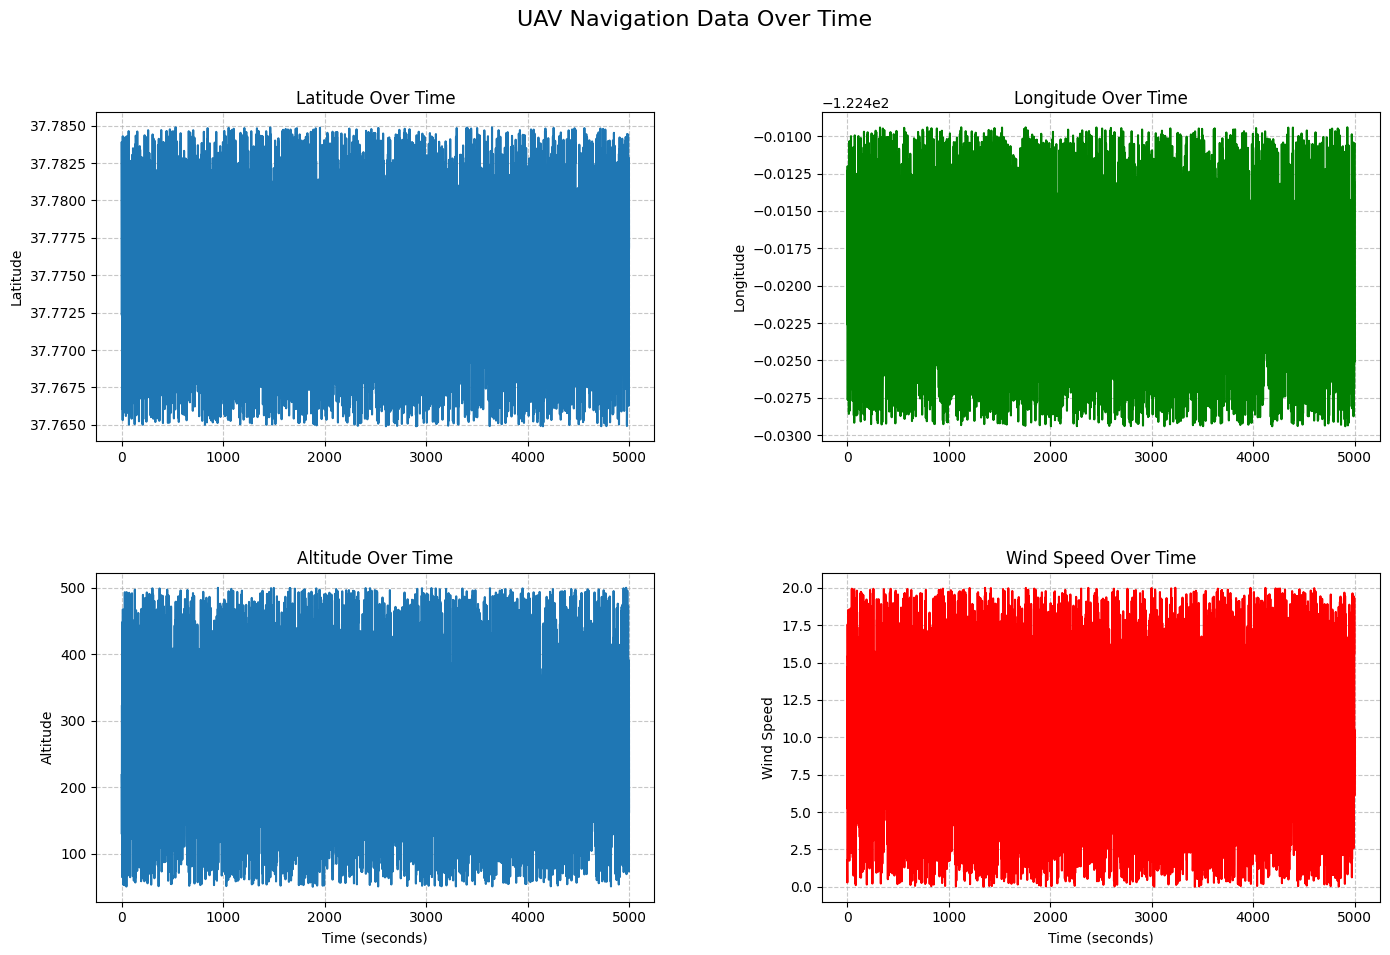

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UAV Navigation Data Over Time', fontsize=16)

# Plot Latitude
axes[0, 0].plot(df_subset['latitude'])
axes[0, 0].set_title('Latitude Over Time')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot Longitude
axes[0, 1].plot(df_subset['longitude'],color="green")
axes[0, 1].set_title('Longitude Over Time')
axes[0, 1].set_ylabel('Longitude')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot Altitude
axes[1, 0].plot(df_subset['altitude'])
axes[1, 0].set_title('Altitude Over Time')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Altitude')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot Wind Speed
axes[1, 1].plot(df_subset['wind_speed'],color="red")
axes[1, 1].set_title('Wind Speed Over Time')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Wind Speed')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.subplots_adjust(wspace=0.3, hspace=0.4) # Adjust padding between subplots
plt.show()

### Plot Explanations

*   **Latitude Over Time:** This plot shows the variation of the UAV's latitude over the recorded time. It indicates the north-south movement of the drone. The plot displays rapid fluctuations, suggesting frequent adjustments or environmental disturbances rather than a smooth, continuous path.
*   **Longitude Over Time:** This plot displays the changes in the UAV's longitude throughout the flight, illustrating its east-west movement. Similar to latitude, it exhibits high-frequency oscillations, indicating dynamic movement along the east-west axis.
*   **Altitude Over Time:** This graph represents the UAV's altitude (height) at different points in time, revealing its vertical movement and any changes in elevation. The altitude appears to fluctuate significantly within a certain range, possibly due to maintaining a target altitude in varying conditions or sensor noise.
*   **Wind Speed Over Time:** This plot illustrates how the wind speed varied during the recorded period, which can impact the UAV's navigation and stability. The wind speed also shows considerable variability, with rapid changes that could influence the drone's flight stability and trajectory.

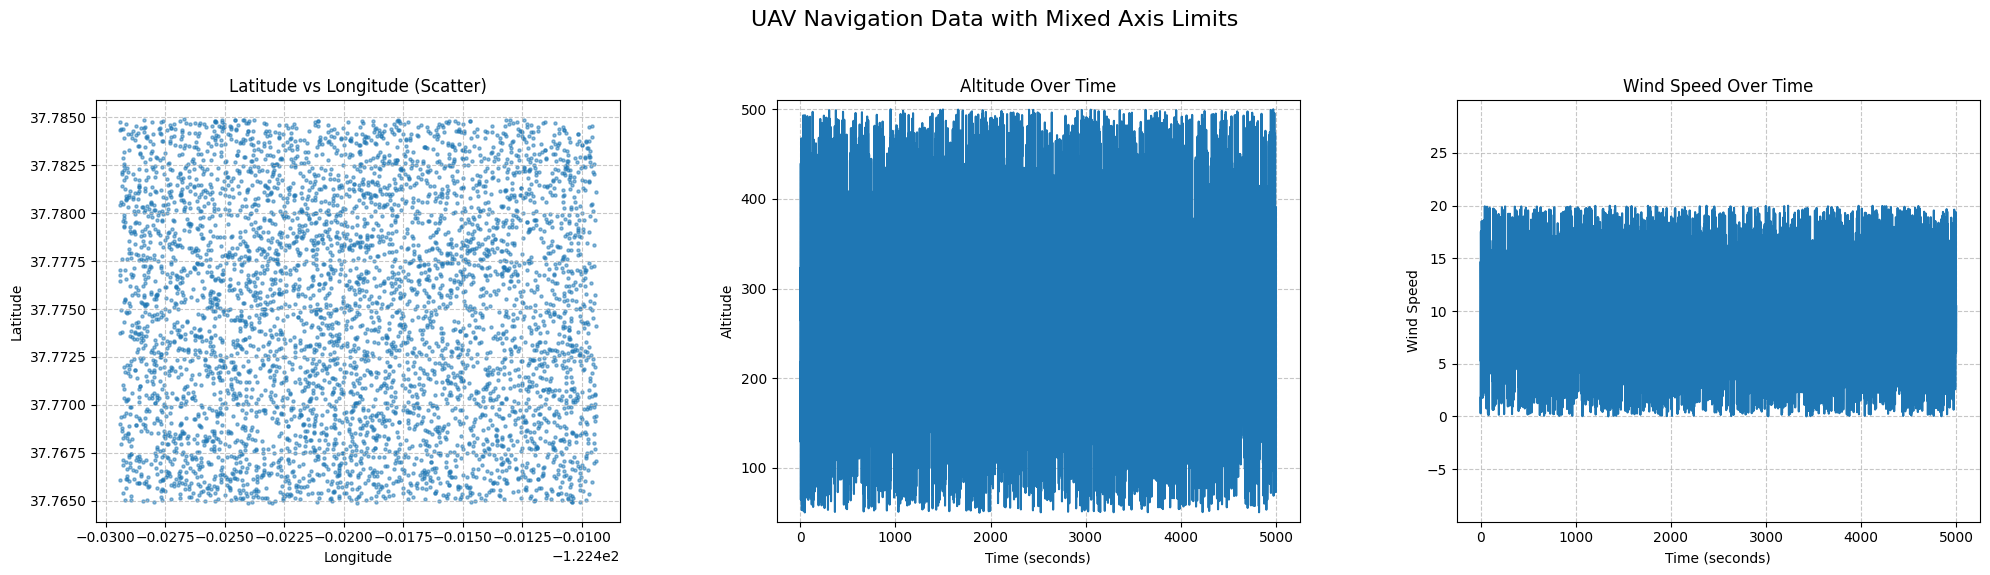

In [11]:
min_lat, max_lat = df_subset['latitude'].min(), df_subset['latitude'].max()
min_lon, max_lon = df_subset['longitude'].min(), df_subset['longitude'].max()
min_alt, max_alt = df_subset['altitude'].min(), df_subset['altitude'].max()
min_wind, max_wind = df_subset['wind_speed'].min(), df_subset['wind_speed'].max()

# lowest value -10 to highest value +10
lat_lim_low, lat_lim_high = min_lat - 10, max_lat + 10
lon_lim_low, lon_lim_high = min_lon - 10, max_lon + 10
alt_lim_low, alt_lim_high = min_alt - 10, max_alt + 10
wind_lim_low, wind_lim_high = min_wind - 10, max_wind + 10
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 1 row, 3 columns
fig.suptitle('UAV Navigation Data with Mixed Axis Limits', fontsize=16)
# Subplot 1: Latitude vs Longitude Scatter Plot
axes[0].scatter(df_subset['longitude'], df_subset['latitude'], s=5, alpha=0.5)
axes[0].set_title('Latitude vs Longitude (Scatter)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
# Removed custom xlim and ylim for latitude and longitude
axes[0].grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Altitude Line Plot
axes[1].plot(df_subset['altitude'])
axes[1].set_title('Altitude Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Altitude')
axes[1].set_ylim(alt_lim_low, alt_lim_high)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Subplot 3: Wind Speed Line Plot (interpreting 'noise' as wind speed variability)
axes[2].plot(df_subset['wind_speed'])
axes[2].set_title('Wind Speed Over Time')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Wind Speed')
axes[2].set_ylim(wind_lim_low, wind_lim_high)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.subplots_adjust(wspace=0.3, hspace=0.4) # Adjust padding between subplots
plt.show()

In [14]:
df_subset.describe()

,latitude,longitude,altitude,wind_speed
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,37.774837,-122.419570,275.618774,10.042630
std,0.005793,0.005712,130.846418,5.768743
min,37.764900,-122.429399,50.070985,0.000169
25%,37.769777,-122.424457,161.225297,5.168707
50%,37.774900,-122.419681,273.288710,10.056165
75%,37.779862,-122.414733,392.278552,15.096536
max,37.784894,-122.409410,499.912315,19.998794


In [16]:
sorted_latitudes = np.sort(df_subset['latitude'])
sorted_longitudes = np.sort(df_subset['longitude'])

sorted_latitudes
sorted_longitudes

array([-122.42939894, -122.42939518, -122.42939518, ..., -122.40941299,
       -122.40941079, -122.4094099 ])

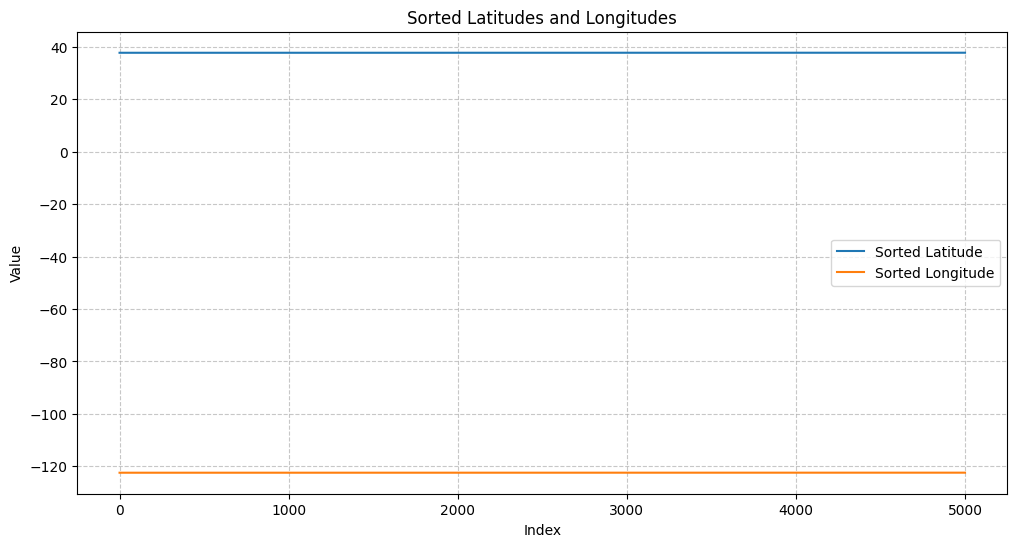

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(sorted_latitudes, label='Sorted Latitude')
plt.plot(sorted_longitudes, label='Sorted Longitude')
plt.title('Sorted Latitudes and Longitudes')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Explanation
1. Since there is not much change in lats and lons, the plot is a straight line parallel to X-axis.  
2. Now, to implement a PID loop we need to specify a dummy point as our target location  
3. Before that, we will first join the wind_speed and with lat and lon data and add a gaussian noise to it, to simulate near real-flight scenario

In [18]:
# adding wind_speed and gaussian noise to the lat and lon readings
df_subset['latitude'] = df_subset['latitude'] + df['wind_speed'] + np.random.normal(0,5,len(df_subset))
df_subset['longitude'] = df_subset['longitude'] + df['wind_speed'] + np.random.normal(0,5,len(df_subset))

/tmp/ipykernel_1724/2565585937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['latitude'] = df_subset['latitude'] + df['wind_speed'] + np.random.normal(0,5,len(df_subset))
/tmp/ipykernel_1724/2565585937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['longitude'] = df_subset['longitude'] + df['wind_speed'] + np.random.normal(0,5,len(df_subset))


In [19]:
# dropping the wind_speed column
df_subset = df_subset.drop('wind_speed', axis=1)

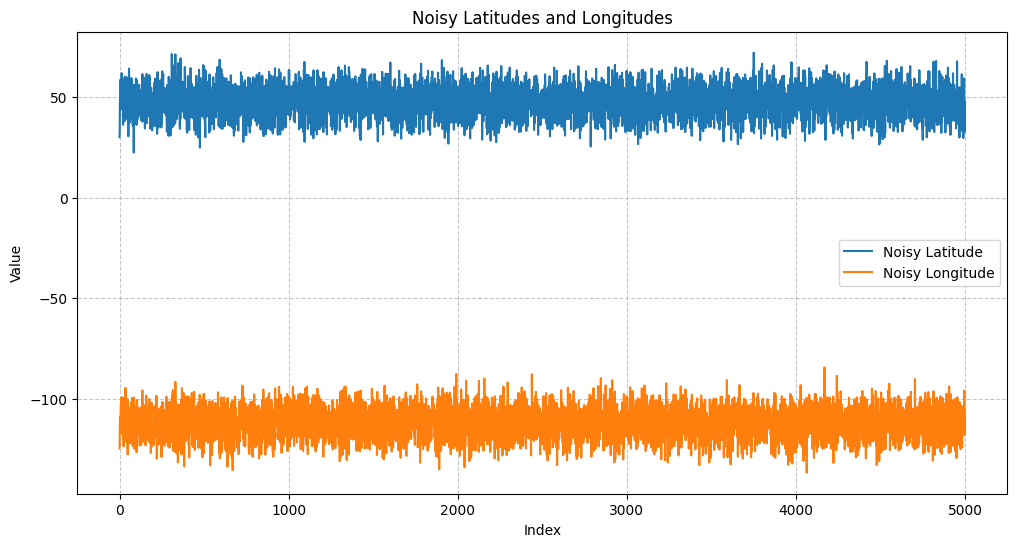

In [21]:
# plotting lat and lon
plt.figure(figsize=(12, 6))
plt.plot(df_subset['latitude'], label='Noisy Latitude')
plt.plot(df_subset['longitude'], label='Noisy Longitude')
plt.title('Noisy Latitudes and Longitudes')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()